# Training Notebook — Dựa trên Feature Engineering Optimized

**Pipeline:**
```
Feature_Engineering_Optimized.ipynb  →  train/test_features.parquet
         ↓
   M1: Ridge (Fourier anchor)
   M2: LightGBM base  (era-weighted, high_era 2014-2018)
   M3: Prophet        (post-2020 only)
   M4-M7: Q-Specialist LightGBM × 4  (Q1–Q4, boost=2×)
         ↓
   Ensemble phân tầng 3 tầng:
     Tầng 1: LGB_blend = (1−α)·base + α·Q-spec   [α=0.60]
     Tầng 2: raw = 0.10·Ridge + 0.10·Prophet + 0.80·LGB_blend
     Tầng 3: final = CR × raw_rev | CC × raw_cogs [tune trên LB]
```

**Lưu ý quan trọng:**  
- Chạy `Feature_Engineering_Optimized.ipynb` trước để tạo `data/train_features.parquet` và `data/test_features.parquet`
- NaN trong window features (`days_since_*`, `days_until_*`) → LightGBM xử lý tự nhiên; Ridge cần `fillna(0)`

## 0. Imports & Load

In [ ]:
import numpy as np
import pandas as pd
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# DATA_PATH is configurable via environment variable `DATA_PATH`. Default to local `data/`.
# If running in Colab, the notebook will detect Colab and use the usual Drive path if no env var is set.
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

default_colab_path = '/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1' if IN_COLAB else None
DATA_PATH = os.environ.get('DATA_PATH', default_colab_path or 'data')
if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)

# -- Load features --
train_feat = pd.read_parquet(f'{DATA_PATH}/train_features.parquet')
test_feat  = pd.read_parquet(f'{DATA_PATH}/test_features.parquet')

with open(f'{DATA_PATH}/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

sample_sub = pd.read_csv(f'{DATA_PATH}/sample_submission.csv', parse_dates=['Date'])
sample_sub = sample_sub.sort_values('Date').reset_index(drop=True)

# -- Arrays cho LightGBM (giu nguyen NaN) --
X_train = train_feat[FEATURE_COLS].values
X_test  = test_feat[FEATURE_COLS].values

# -- Arrays cho Ridge: chi dung feature khong co NaN o ca train va test --
RIDGE_FEATURE_COLS = [
    c for c in FEATURE_COLS
    if (not train_feat[c].isna().any()) and (not test_feat[c].isna().any())
]
X_train_r = train_feat[RIDGE_FEATURE_COLS].values
X_test_r  = test_feat[RIDGE_FEATURE_COLS].values

y_rev  = np.log(train_feat['Revenue'].values)
y_cogs = np.log(train_feat['COGS'].values)

years           = train_feat['year'].values
quarters_train  = train_feat['quarter'].values
quarters_test   = test_feat['quarter'].values
dates_train     = pd.to_datetime(train_feat['Date'].values)

print(f'X_train (LGB): {X_train.shape}')
print(f'X_test  (LGB): {X_test.shape}')
print(f'Features (LGB): {len(FEATURE_COLS)}')
print(f'X_train (Ridge): {X_train_r.shape}')
print(f'Features (Ridge): {len(RIDGE_FEATURE_COLS)}')
print(f'Train period: {train_feat["Date"].min().date()} -> {train_feat["Date"].max().date()}')
print(f'Test  period: {test_feat["Date"].min().date()} -> {test_feat["Date"].max().date()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train (LGB): (3833, 122)
X_test  (LGB): (548, 122)
Features (LGB): 122
X_train (Ridge): (3833, 99)
Features (Ridge): 99
Train period: 2012-07-04 -> 2022-12-31
Test  period: 2023-01-01 -> 2024-07-01


## 1. Helpers: Metrics & Sample Weights

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{label:<28} | MAE: {mae:>12,.0f} | RMSE: {rmse:>12,.0f} | R2: {r2:>7.4f}')
    return mae, rmse, r2


def make_sample_weights(years_arr, scheme='high_era'):
    """
    high_era: giu dung baseline AIO
              - 2014-2018: weight 1.0 (vung seasonality ro nhat)
              - cac nam con lai: 0.01
    """
    w = np.full(len(years_arr), 0.01)
    if scheme == 'high_era':
        w[(years_arr >= 2014) & (years_arr <= 2018)] = 1.0
    elif scheme == 'recent_heavy':
        w[years_arr >= 2020]                          = 1.0
        w[(years_arr >= 2017) & (years_arr < 2020)]  = 0.6
        w[(years_arr >= 2014) & (years_arr < 2017)]  = 0.3
    elif scheme == 'uniform':
        w[:] = 1.0
    return w


FOLDS = {
    'A_primary':   ('2022-01-01', '2022-12-31'),
    'B_stability': ('2021-01-01', '2021-12-31'),
    'C_horizon':   ('2021-07-01', '2022-06-30'),
}

def get_fold(dates_arr, val_start, val_end):
    val_start = pd.Timestamp(val_start)
    val_end   = pd.Timestamp(val_end)
    tr  = dates_arr <  val_start
    va  = (dates_arr >= val_start) & (dates_arr <= val_end)
    return tr, va

w_base = make_sample_weights(years, 'high_era')

print('Sample weight distribution:')
for label, mask in [
    ('2012-2013 (noisy)',    years < 2014),
    ('2014-2018 (peak era)', (years >= 2014) & (years <= 2018)),
    ('2019 (transition)',    years == 2019),
    ('2020-2022 (recent)',   years >= 2020),
]:
    print(f'  {label:<28}: w={w_base[mask][0]:.2f}, n={mask.sum()}')

Sample weight distribution:
  2012-2013 (noisy)           : w=0.01, n=546
  2014-2018 (peak era)        : w=1.00, n=1826
  2019 (transition)           : w=0.01, n=365
  2020-2022 (recent)          : w=0.01, n=1096


## 2. M1 — Ridge Regression (Fourier anchor)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def train_ridge(X_tr, y_tr, alpha=3.0):
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X_tr)
    model  = Ridge(alpha=alpha, random_state=SEED)
    model.fit(Xs, y_tr)
    return model, scaler

def predict_ridge(model, scaler, X):
    return model.predict(scaler.transform(X))

# ── CV Fold A ──
tr_mask, va_mask = get_fold(dates_train, *FOLDS['A_primary'])

ridge_cv_rev,  sc_cv_rev  = train_ridge(X_train_r[tr_mask], y_rev[tr_mask])
ridge_cv_cogs, sc_cv_cogs = train_ridge(X_train_r[tr_mask], y_cogs[tr_mask])

p_ridge_cv_rev  = np.exp(predict_ridge(ridge_cv_rev,  sc_cv_rev,  X_train_r[va_mask]))
p_ridge_cv_cogs = np.exp(predict_ridge(ridge_cv_cogs, sc_cv_cogs, X_train_r[va_mask]))

y_val_rev  = train_feat['Revenue'].values[va_mask]
y_val_cogs = train_feat['COGS'].values[va_mask]

print('=== Ridge — Fold A Validation ===')
eval_metrics(y_val_rev,  p_ridge_cv_rev,  'Ridge Revenue')
eval_metrics(y_val_cogs, p_ridge_cv_cogs, 'Ridge COGS')

# ── Full train ──
ridge_rev,  sc_rev  = train_ridge(X_train_r, y_rev)
ridge_cogs, sc_cogs = train_ridge(X_train_r, y_cogs)

p_ridge_rev  = np.exp(predict_ridge(ridge_rev,  sc_rev,  X_test_r))
p_ridge_cogs = np.exp(predict_ridge(ridge_cogs, sc_cogs, X_test_r))

print(f'\nRidge Revenue  test mean: {p_ridge_rev.mean():>12,.0f}')
print(f'Ridge COGS     test mean: {p_ridge_cogs.mean():>12,.0f}')

=== Ridge — Fold A Validation ===
Ridge Revenue                | MAE:      705,878 | RMSE:    1,028,145 | R2:  0.6227
Ridge COGS                   | MAE:      647,724 | RMSE:      930,320 | R2:  0.5932

Ridge Revenue  test mean:    3,034,223
Ridge COGS     test mean:    2,723,647


## 3. M2 — LightGBM Base (era-weighted, 2-stage training)

In [ ]:
import lightgbm as lgb

LGB_PARAMS = dict(
    objective        = 'regression',
    metric           = 'mae',
    learning_rate    = 0.03,
    num_leaves       = 63,
    min_data_in_leaf = 30,
    feature_fraction = 0.85,
    bagging_fraction = 0.85,
    bagging_freq     = 5,
    lambda_l2        = 1.0,
    seed             = SEED,
    verbosity        = -1,
    n_jobs           = -1,
)

def train_lgb_two_stage(X_tr, y_tr, sample_w, params=LGB_PARAMS,
                         holdout_days=180, n_round=6000, verbose_eval=500):
    """
    Stage 1: tìm best_iteration qua early stopping trên 180 ngày cuối.
    Stage 2: retrain toàn bộ với best_iteration → tận dụng hết data.
    """
    split   = len(X_tr) - holdout_days
    Xf, Xh = X_tr[:split], X_tr[split:]
    yf, yh = y_tr[:split], y_tr[split:]
    wf      = sample_w[:split]

    ds_fit  = lgb.Dataset(Xf, label=yf, weight=wf)
    ds_hold = lgb.Dataset(Xh, label=yh, reference=ds_fit)

    booster_es = lgb.train(
        params, ds_fit,
        num_boost_round = n_round,
        valid_sets      = [ds_hold],
        callbacks       = [
            lgb.early_stopping(300, verbose=False),
            lgb.log_evaluation(verbose_eval)
        ]
    )
    best_iter = booster_es.best_iteration
    print(f'  Early stopping @ iter {best_iter}')

    # Stage 2: retrain full
    ds_full = lgb.Dataset(X_tr, label=y_tr, weight=sample_w)
    booster = lgb.train(
        params, ds_full,
        num_boost_round = best_iter,
    )
    return booster, best_iter


# ── CV Fold A ──
print('=== LGB Base — Fold A CV ===')
w_cv = make_sample_weights(years[tr_mask], 'high_era')
lgb_cv, bi_cv = train_lgb_two_stage(X_train[tr_mask], y_rev[tr_mask], w_cv, verbose_eval=0)
p_lgb_cv = np.exp(lgb_cv.predict(X_train[va_mask]))
eval_metrics(y_val_rev, p_lgb_cv, 'LGB Base Revenue')

# Diversity check
corr_ridge_lgb = np.corrcoef(y_val_rev - p_ridge_cv_rev, y_val_rev - p_lgb_cv)[0, 1]
print(f'  Residual corr (Ridge vs LGB): {corr_ridge_lgb:.3f}  (lý tưởng: 0.6–0.7)')

=== LGB Base — Fold A CV ===
  Early stopping @ iter 310
LGB Base Revenue             | MAE:      606,418 | RMSE:      840,418 | R2:  0.7479
  Residual corr (Ridge vs LGB): 0.536  (lý tưởng: 0.6–0.7)


In [ ]:
# ── Full train ──
print('=== LGB Base — Full Train ===')
print('  Revenue:')
lgb_base_rev,  bi_rev  = train_lgb_two_stage(X_train, y_rev,  w_base, verbose_eval=0)
print('  COGS:')
lgb_base_cogs, bi_cogs = train_lgb_two_stage(X_train, y_cogs, w_base, verbose_eval=0)

p_lgb_rev  = np.exp(lgb_base_rev.predict(X_test))
p_lgb_cogs = np.exp(lgb_base_cogs.predict(X_test))

print(f'\nLGB Revenue  test mean: {p_lgb_rev.mean():>12,.0f}')
print(f'LGB COGS     test mean: {p_lgb_cogs.mean():>12,.0f}')

=== LGB Base — Full Train ===
  Revenue:
  Early stopping @ iter 525
  COGS:
  Early stopping @ iter 415

LGB Revenue  test mean:    3,366,437
LGB COGS     test mean:    2,916,542


## 4. M3 — Prophet (post-2020, với promo regressors)

In [ ]:
try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    print('Prophet chưa install → pip install prophet\nDùng Ridge làm fallback.')
    PROPHET_OK = False

TET_DATES = {
    2012:'2012-01-23', 2013:'2013-02-10', 2014:'2014-01-31',
    2015:'2015-02-19', 2016:'2016-02-08', 2017:'2017-01-28',
    2018:'2018-02-16', 2019:'2019-02-05', 2020:'2020-01-25',
    2021:'2021-02-12', 2022:'2022-02-01', 2023:'2023-01-22',
    2024:'2024-02-10', 2025:'2025-01-29',
}

# Promo columns có trong feature set
PROMO_NAMES = ['spring_sale','mid_year','fall_launch','year_end','urban_blowout','rural_special']
PROMO_COLS  = [f'promo_{n}' for n in PROMO_NAMES]

if PROPHET_OK:
    def fit_prophet(df_train, target_col, post_regime_only=True):
        """
        post_regime_only=True: chỉ train 2020–2022.
        Tránh bị kéo bởi level cũ (regime drift).
        """
        cols_needed = ['Date', target_col] + PROMO_COLS
        df = df_train[cols_needed].copy()
        df = df.rename(columns={'Date': 'ds', target_col: 'y'})
        df['y'] = np.log(df['y'])

        if post_regime_only:
            df = df[df['ds'] >= '2020-01-01']

        # Tết holidays với window trước và sau
        tet_df = pd.DataFrame({
            'holiday':       'tet',
            'ds':            [pd.Timestamp(v) for v in TET_DATES.values()],
            'lower_window':  -7,
            'upper_window':  21,
        })

        m = Prophet(
            yearly_seasonality      = True,
            weekly_seasonality      = True,
            daily_seasonality       = False,
            seasonality_mode        = 'multiplicative',
            changepoint_prior_scale = 0.05,
            holidays                = tet_df,
        )
        for col in PROMO_COLS:
            m.add_regressor(col)
        m.fit(df)
        return m

    print('Training Prophet Revenue...')
    prophet_rev  = fit_prophet(train_feat, 'Revenue',  post_regime_only=True)
    print('Training Prophet COGS...')
    prophet_cogs = fit_prophet(train_feat, 'COGS',     post_regime_only=True)

    # Predict test
    future_df = test_feat[['Date'] + PROMO_COLS].rename(columns={'Date': 'ds'})
    p_prophet_rev  = np.maximum(np.exp(prophet_rev.predict(future_df)['yhat'].values),  0)
    p_prophet_cogs = np.maximum(np.exp(prophet_cogs.predict(future_df)['yhat'].values), 0)

    print(f'\nProphet Revenue  test mean: {p_prophet_rev.mean():>12,.0f}')
    print(f'Prophet COGS     test mean: {p_prophet_cogs.mean():>12,.0f}')

else:
    # Fallback: dùng Ridge thay thế
    p_prophet_rev  = p_ridge_rev.copy()
    p_prophet_cogs = p_ridge_cogs.copy()
    print('Fallback: dùng Ridge thay Prophet.')

Training Prophet Revenue...
Training Prophet COGS...

Prophet Revenue  test mean:    3,596,950
Prophet COGS     test mean:    3,205,873


## 5. M4–M7 — Q-Specialist LightGBM (4 × 2 = 8 models)

In [ ]:
Q_BOOST = 2.0   # hệ số nhân weight cho quý phụ trách

spec_preds = {'rev': {}, 'cogs': {}}  # {q: np.array}

for q in [1, 2, 3, 4]:
    print(f'\n=== Q{q} Specialist ===')

    # Layer 1: high_era base
    w_spec = make_sample_weights(years, 'high_era').copy()
    # Layer 2: boost quý phụ trách lên 2×
    w_spec[quarters_train == q] *= Q_BOOST

    # Revenue specialist
    print('  Revenue:')
    spec_r, bi_r = train_lgb_two_stage(X_train, y_rev,  w_spec, verbose_eval=0)
    spec_preds['rev'][q]  = np.exp(spec_r.predict(X_test))

    # COGS specialist
    print('  COGS:')
    spec_c, bi_c = train_lgb_two_stage(X_train, y_cogs, w_spec, verbose_eval=0)
    spec_preds['cogs'][q] = np.exp(spec_c.predict(X_test))

    q_mask = quarters_test == q
    print(f'  Rev  Q{q} mean: {spec_preds["rev"][q][q_mask].mean():>12,.0f} | iter={bi_r}')
    print(f'  COGS Q{q} mean: {spec_preds["cogs"][q][q_mask].mean():>12,.0f} | iter={bi_c}')

# Ghép specialist predictions: dùng Spec_Qq CHỈ cho ngày thuộc quý q
p_spec_rev  = np.zeros(len(test_feat))
p_spec_cogs = np.zeros(len(test_feat))
for q in [1, 2, 3, 4]:
    mask = quarters_test == q
    p_spec_rev[mask]  = spec_preds['rev'][q][mask]
    p_spec_cogs[mask] = spec_preds['cogs'][q][mask]

print(f'\nSpec Revenue  test mean: {p_spec_rev.mean():>12,.0f}')
print(f'Spec COGS     test mean: {p_spec_cogs.mean():>12,.0f}')


=== Q1 Specialist ===
  Revenue:
  Early stopping @ iter 805
  COGS:
  Early stopping @ iter 747
  Rev  Q1 mean:    2,818,038 | iter=805
  COGS Q1 mean:    2,399,643 | iter=747

=== Q2 Specialist ===
  Revenue:
  Early stopping @ iter 326
  COGS:
  Early stopping @ iter 1360
  Rev  Q2 mean:    4,829,670 | iter=326
  COGS Q2 mean:    3,978,061 | iter=1360

=== Q3 Specialist ===
  Revenue:
  Early stopping @ iter 351
  COGS:
  Early stopping @ iter 363
  Rev  Q3 mean:    2,836,907 | iter=351
  COGS Q3 mean:    3,112,601 | iter=363

=== Q4 Specialist ===
  Revenue:
  Early stopping @ iter 352
  COGS:
  Early stopping @ iter 679
  Rev  Q4 mean:    1,905,444 | iter=352
  COGS Q4 mean:    1,709,112 | iter=679

Spec Revenue  test mean:    3,336,128
Spec COGS     test mean:    2,928,928


## 6. Ensemble phân tầng 3 tầng

In [ ]:
# =========================================================
# Hyperparameters ensemble
# =========================================================
ALPHA     = 0.60
W_RIDGE   = 0.10
W_PROPHET = 0.10
W_LGB     = 0.80

# Neu da tune o Muc 10, uu tien dung cap BEST_CR/BEST_CC
if 'BEST_CR' not in globals():
    BEST_CR = 1.30
if 'BEST_CC' not in globals():
    BEST_CC = 1.32

CR = BEST_CR
CC = BEST_CC

# -- Tang 1: LGB internal blend --
lgb_blend_rev  = ALPHA * p_spec_rev  + (1 - ALPHA) * p_lgb_rev
lgb_blend_cogs = ALPHA * p_spec_cogs + (1 - ALPHA) * p_lgb_cogs

# -- Tang 2: 3-way blend --
raw_rev  = W_RIDGE * p_ridge_rev  + W_PROPHET * p_prophet_rev  + W_LGB * lgb_blend_rev
raw_cogs = W_RIDGE * p_ridge_cogs + W_PROPHET * p_prophet_cogs + W_LGB * lgb_blend_cogs

# -- Tang 3: Calibration --
final_rev  = CR * raw_rev
final_cogs = CC * raw_cogs

print('=== Final Predictions ===')
print(f'Calibration dang dung: CR={CR:.4f}, CC={CC:.4f}')
print(f'Revenue: mean={final_rev.mean():>10,.0f} | min={final_rev.min():>10,.0f} | max={final_rev.max():>10,.0f}')
print(f'COGS   : mean={final_cogs.mean():>10,.0f} | min={final_cogs.min():>10,.0f} | max={final_cogs.max():>10,.0f}')
print(f'Margin (COGS/Rev): {(final_cogs / final_rev).mean():.3f}')

train_2022 = train_feat[train_feat['year'] == 2022]
print(f'\nSanity: 2022 train Rev mean  = {train_2022["Revenue"].mean():>12,.0f}')
print(f'Sanity: 2023 pred  Rev mean  = {final_rev[test_feat["year"] == 2023].mean():>12,.0f}')

=== Final Predictions ===
Calibration dang dung: CR=1.3000, CC=1.3200
Revenue: mean= 4,344,234 | min= 1,071,345 | max=13,271,993
COGS   : mean= 3,870,413 | min=   983,587 | max=11,693,667
Margin (COGS/Rev): 0.909

Sanity: 2022 train Rev mean  =    3,204,791
Sanity: 2023 pred  Rev mean  =    4,014,808


## 7. Validation tổng hợp trên Fold A

In [ ]:
# Đánh giá từng model + ensemble trên Fold A để quyết định ALPHA và weights
print('=== Fold A Revenue — Model Comparison ===')
print(f'{"Model":<28} | {"MAE":>12} | {"RMSE":>12} | {"R²":>7}')
print('-' * 70)

eval_metrics(y_val_rev, p_ridge_cv_rev, 'M1: Ridge')
eval_metrics(y_val_rev, p_lgb_cv,       'M2: LGB Base')

# Simple blend (2 models) để xem hướng cải thiện
blend_simple = 0.2 * p_ridge_cv_rev + 0.8 * p_lgb_cv
eval_metrics(y_val_rev, blend_simple, 'Blend 0.2R+0.8L')

print('\n(Prophet và Q-Specialist cần thêm CV fold riêng để evaluate)')
print('\nQuy tắc: nếu blend cải thiện MAE > 2% → ensemble có giá trị.')

# Diversity metric
print(f'\nDiversity (residual corr Ridge vs LGB): {corr_ridge_lgb:.3f}')

=== Fold A Revenue — Model Comparison ===
Model                        |          MAE |         RMSE |      R²
----------------------------------------------------------------------
M1: Ridge                    | MAE:      705,878 | RMSE:    1,028,145 | R2:  0.6227
M2: LGB Base                 | MAE:      606,418 | RMSE:      840,418 | R2:  0.7479
Blend 0.2R+0.8L              | MAE:      585,520 | RMSE:      799,369 | R2:  0.7719

(Prophet và Q-Specialist cần thêm CV fold riêng để evaluate)

Quy tắc: nếu blend cải thiện MAE > 2% → ensemble có giá trị.

Diversity (residual corr Ridge vs LGB): 0.536


## 8. Feature Importance

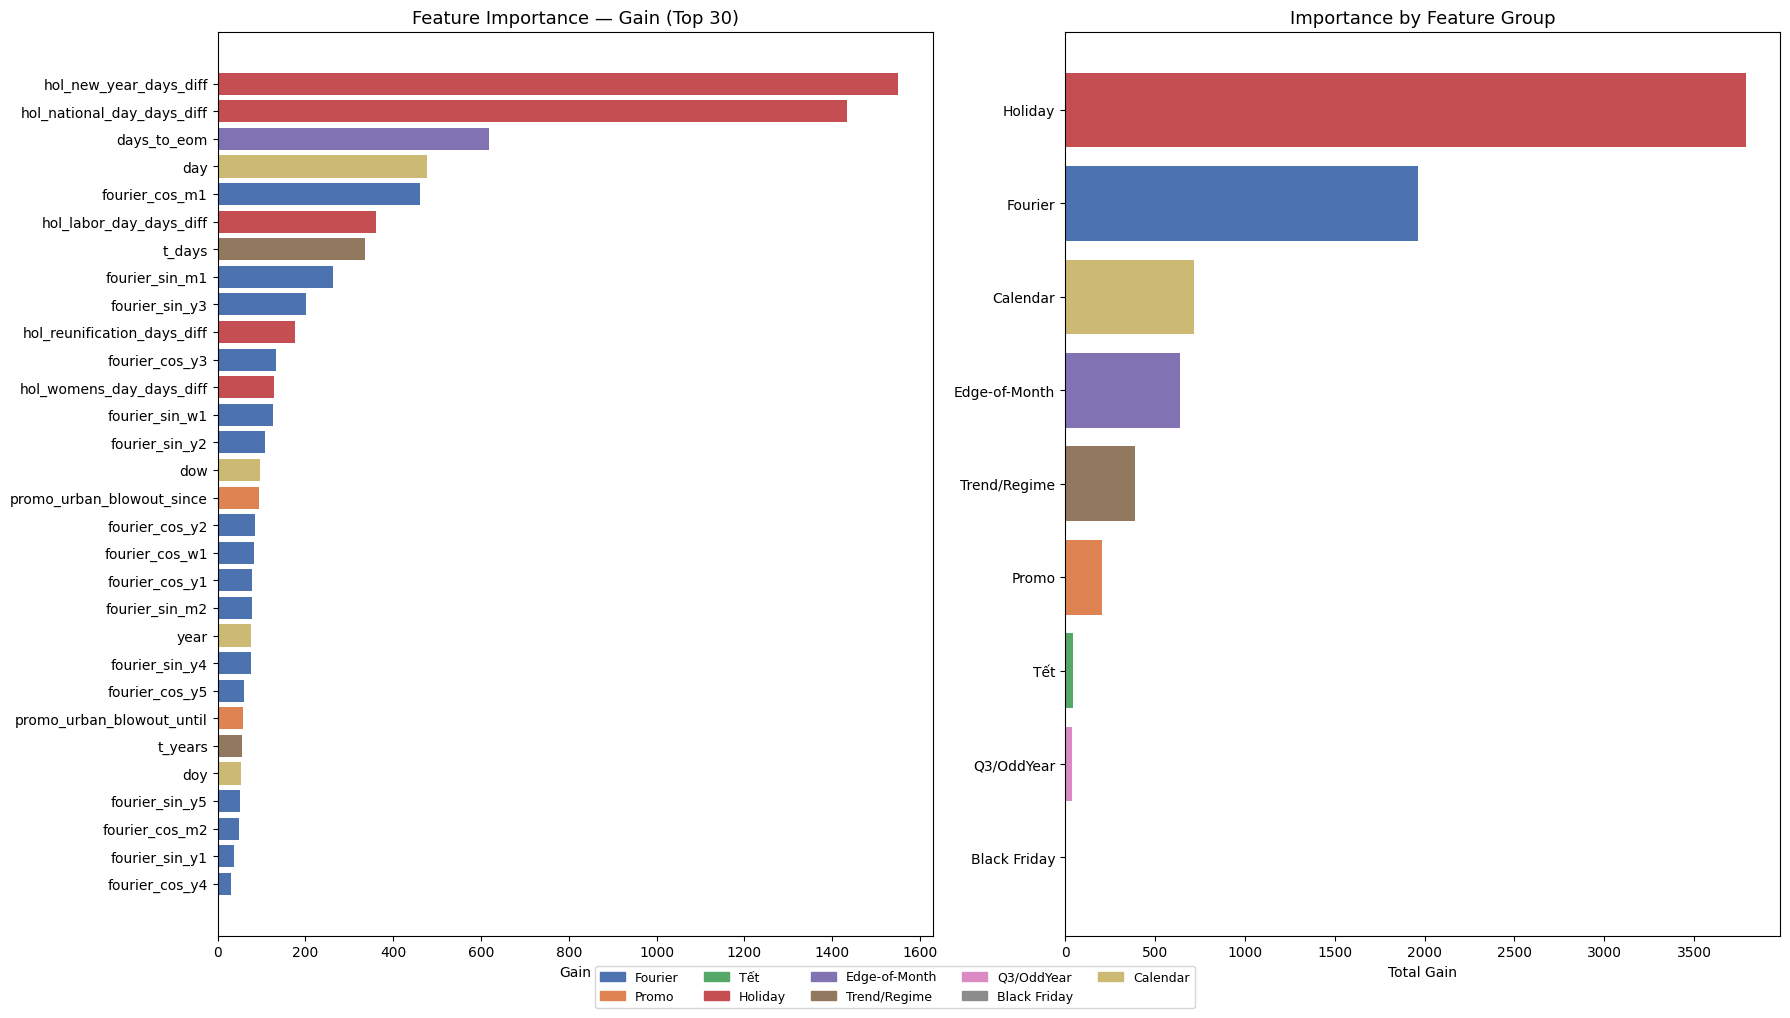


Top 20 features (Gain):
                    feature         group        gain
     hol_new_year_days_diff       Holiday 1550.740945
 hol_national_day_days_diff       Holiday 1433.095041
                days_to_eom Edge-of-Month  617.762560
                        day      Calendar  476.486525
             fourier_cos_m1       Fourier  462.104308
    hol_labor_day_days_diff       Holiday  361.279684
                     t_days  Trend/Regime  336.776432
             fourier_sin_m1       Fourier  263.608747
             fourier_sin_y3       Fourier  201.500227
hol_reunification_days_diff       Holiday  175.224744
             fourier_cos_y3       Fourier  133.234522
   hol_womens_day_days_diff       Holiday  129.342467
             fourier_sin_w1       Fourier  126.301812
             fourier_sin_y2       Fourier  108.784964
                        dow      Calendar   96.426314
  promo_urban_blowout_since         Promo   93.620997
             fourier_cos_y2       Fourier   86.121642
   

In [ ]:
imp_gain  = lgb_base_rev.feature_importance(importance_type='gain')
imp_split = lgb_base_rev.feature_importance(importance_type='split')

feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain':    imp_gain,
    'split':   imp_split,
}).sort_values('gain', ascending=False)

# Nhóm feature groups để phân tích
def get_group(col):
    if 'fourier' in col:            return 'Fourier'
    if col.startswith('promo_'):    return 'Promo'
    if 'tet' in col:                return 'Tết'
    if 'hol_' in col or 'on_' in col or 'days_since_hol' in col or 'days_until_hol' in col:
                                    return 'Holiday'
    if col in ['is_last1','is_last2','is_last3','is_first1','is_first2','is_first3',
               'days_to_eom','days_from_som']: return 'Edge-of-Month'
    if 'regime' in col or 't_days' in col or 't_years' in col: return 'Trend/Regime'
    if col in ['q3_odd','q3_even','is_odd_year']:               return 'Q3/OddYear'
    if 'black_friday' in col:       return 'Black Friday'
    return 'Calendar'

feat_imp['group'] = feat_imp['feature'].apply(get_group)

# Plot top 30
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

top30 = feat_imp.head(30)
colors = {
    'Fourier': '#4C72B0', 'Promo': '#DD8452', 'Tết': '#55A868',
    'Holiday': '#C44E52', 'Edge-of-Month': '#8172B3',
    'Trend/Regime': '#937860', 'Q3/OddYear': '#DA8BC3',
    'Black Friday': '#8C8C8C', 'Calendar': '#CCB974',
}
bar_colors = top30['group'].map(colors)

ax1.barh(top30['feature'], top30['gain'], color=bar_colors)
ax1.set_title('Feature Importance — Gain (Top 30)', fontsize=13)
ax1.set_xlabel('Gain')
ax1.invert_yaxis()

# Group-level importance
group_gain = feat_imp.groupby('group')['gain'].sum().sort_values(ascending=False)
group_colors = [colors.get(g, '#999') for g in group_gain.index]
ax2.barh(group_gain.index, group_gain.values, color=group_colors)
ax2.set_title('Importance by Feature Group', fontsize=13)
ax2.set_xlabel('Total Gain')
ax2.invert_yaxis()

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=g) for g, c in colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('feature_importance_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 features (Gain):')
print(feat_imp[['feature', 'group', 'gain']].head(20).to_string(index=False))

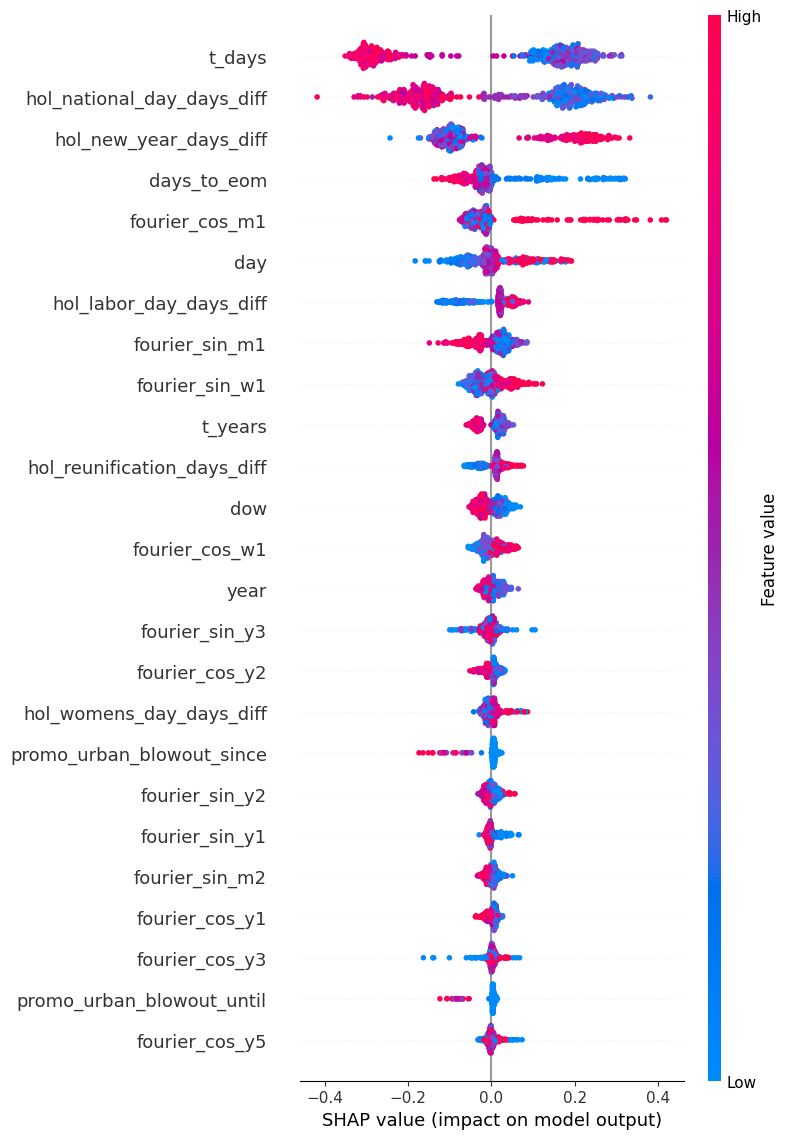

SHAP saved → shap_summary.png


In [ ]:
# SHAP values
try:
    import shap
    explainer   = shap.TreeExplainer(lgb_base_rev)
    idx_sample  = np.random.choice(len(X_train), min(500, len(X_train)), replace=False)
    shap_values = explainer.shap_values(X_train[idx_sample])

    plt.figure(figsize=(10, 9))
    shap.summary_plot(
        shap_values, X_train[idx_sample],
        feature_names=FEATURE_COLS, max_display=25, show=False
    )
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP saved → shap_summary.png')
except ImportError:
    print('pip install shap để xem SHAP plot.')

## 9. Export submission

In [ ]:
assert len(final_rev) == len(sample_sub), \
    f'Số dòng không khớp: pred={len(final_rev)}, sample={len(sample_sub)}'

submission = sample_sub.copy()
submission['Revenue'] = np.round(final_rev,  2)
submission['COGS']    = np.round(final_cogs, 2)
submission = submission.sort_values('Date').reset_index(drop=True)

submission.to_csv(f'{DATA_PATH}/my_submission.csv', index=False)
print(f'Saved: {DATA_PATH}/my_submission.csv')
print(submission.head(5).to_string(index=False))

Saved: /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/my_submission.csv
      Date    Revenue       COGS
2023-01-01 2396797.35 2528138.63
2023-01-02 1696903.11 1669628.07
2023-01-03 1628228.59 1538610.09
2023-01-04 1071345.35  983586.58
2023-01-05 1305955.88 1162869.41


## 10. Calibration tuning — grid search CR × CC

In [ ]:
def make_submission_cr_cc(cr, cc, raw_rev, raw_cogs, sample_sub, tag=''):
    sub = sample_sub.copy()
    sub['Revenue'] = np.round(cr * raw_rev,  2)
    sub['COGS']    = np.round(cc * raw_cogs, 2)
    sub = sub.sort_values('Date').reset_index(drop=True)
    fname = f'{DATA_PATH}/submission_cr{cr}_cc{cc}{tag}.csv'
    sub.to_csv(fname, index=False)
    print(f'  [{fname}]  Rev mean: {sub["Revenue"].mean():>10,.0f} | COGS mean: {sub["COGS"].mean():>10,.0f}')
    return sub

target_rev = train_feat.loc[train_feat['year'] == 2022, 'Revenue'].mean()
target_cog = train_feat.loc[train_feat['year'] == 2022, 'COGS'].mean()

cr_grid = [1.18, 1.22, 1.26, 1.30, 1.34]
cc_grid = [1.28, 1.30, 1.32, 1.34, 1.36]

print('=== CR sweep (CC=1.32 co dinh) ===')
for cr in cr_grid:
    make_submission_cr_cc(cr, 1.32, raw_rev, raw_cogs, sample_sub)

print()
print('=== CC sweep (CR=1.30 co dinh) ===')
for cc in cc_grid:
    make_submission_cr_cc(1.30, cc, raw_rev, raw_cogs, sample_sub)

print()
print('=== Grid search CR x CC (proxy theo muc tieu mean 2022) ===')
rows = []
for cr in cr_grid:
    for cc in cc_grid:
        rev_mean  = (cr * raw_rev).mean()
        cogs_mean = (cc * raw_cogs).mean()
        score = abs(rev_mean - target_rev) / target_rev + abs(cogs_mean - target_cog) / target_cog
        rows.append((cr, cc, rev_mean, cogs_mean, score))

grid_df = pd.DataFrame(rows, columns=['cr', 'cc', 'rev_mean', 'cogs_mean', 'proxy_score'])
grid_df = grid_df.sort_values('proxy_score').reset_index(drop=True)
print(grid_df.head(10).to_string(index=False, float_format=lambda x: f'{x:,.6f}'))

BEST_CR = float(grid_df.loc[0, 'cr'])
BEST_CC = float(grid_df.loc[0, 'cc'])
print(f'\nBest proxy pair: CR={BEST_CR:.2f}, CC={BEST_CC:.2f}')
print('Goi y: submit top 3 cap tren LB de chot cap cuoi cung.')

make_submission_cr_cc(BEST_CR, BEST_CC, raw_rev, raw_cogs, sample_sub, tag='_final')

=== CR sweep (CC=1.32 co dinh) ===
  [/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_cr1.18_cc1.32.csv]  Rev mean:  3,943,228 | COGS mean:  3,870,413
  [/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_cr1.22_cc1.32.csv]  Rev mean:  4,076,897 | COGS mean:  3,870,413
  [/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_cr1.26_cc1.32.csv]  Rev mean:  4,210,565 | COGS mean:  3,870,413
  [/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_cr1.3_cc1.32.csv]  Rev mean:  4,344,234 | COGS mean:  3,870,413
  [/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_cr1.34_cc1.32.csv]  Rev mean:  4,477,903 | COGS mean:  3,870,413

=== CC sweep (CR=1.30 co dinh) ===
  [/content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_cr1.3_cc1.28.csv]  Rev mean:  4,344,234 | COGS mean:  3,753,128
  [/content/drive/MyDrive/AIO2026_Prj

,Date,Revenue,COGS
0,2023-01-01,2175554.52,2451528.37
1,2023-01-02,1540265.90,1619033.28
2,2023-01-03,1477930.57,1491985.55
3,2023-01-04,972451.93,953780.93
4,2023-01-05,1185406.10,1127630.94
...,...,...,...
543,2024-06-27,5662232.50,5960401.97
544,2024-06-28,4936802.34,5014673.25
545,2024-06-29,7701993.06,7943995.64
546,2024-06-30,7212225.53,7098981.68


## 11. ALPHA tuning — sweep trên Fold A

In [ ]:
# Để tune ALPHA cần CV predictions của Q-specialist
# Chạy cell này SAU KHI có Q-specialist CV predictions

print('=== ALPHA sweep trên test predictions (proxy) ===')
print('(Đây là proxy — nên tune trên CV fold nếu có thời gian)')
print()
for alpha in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    blend = alpha * p_spec_rev + (1 - alpha) * p_lgb_rev
    raw   = W_RIDGE * p_ridge_rev + W_PROPHET * p_prophet_rev + W_LGB * blend
    final = CR * raw
    print(f'  α={alpha:.1f} → blend mean: {blend.mean():>10,.0f} | final mean: {final.mean():>10,.0f}')

print()
print('Chọn α mà final mean gần nhất với Rev trung bình 2022 × CR.')
ref = train_feat[train_feat['year'] == 2022]['Revenue'].mean()
print(f'2022 Rev mean × {CR}: {ref * CR:>10,.0f}  ← target tham chiếu')

=== ALPHA sweep trên test predictions (proxy) ===
(Đây là proxy — nên tune trên CV fold nếu có thời gian)

  α=0.3 → blend mean:  3,357,344 | final mean:  4,353,691
  α=0.4 → blend mean:  3,354,313 | final mean:  4,350,538
  α=0.5 → blend mean:  3,351,283 | final mean:  4,347,386
  α=0.6 → blend mean:  3,348,252 | final mean:  4,344,234
  α=0.7 → blend mean:  3,345,221 | final mean:  4,341,082
  α=0.8 → blend mean:  3,342,190 | final mean:  4,337,930

Chọn α mà final mean gần nhất với Rev trung bình 2022 × CR.
2022 Rev mean × 1.3:  4,166,229  ← target tham chiếu


## 12. Forecast visualization — kiểm tra shape dự báo

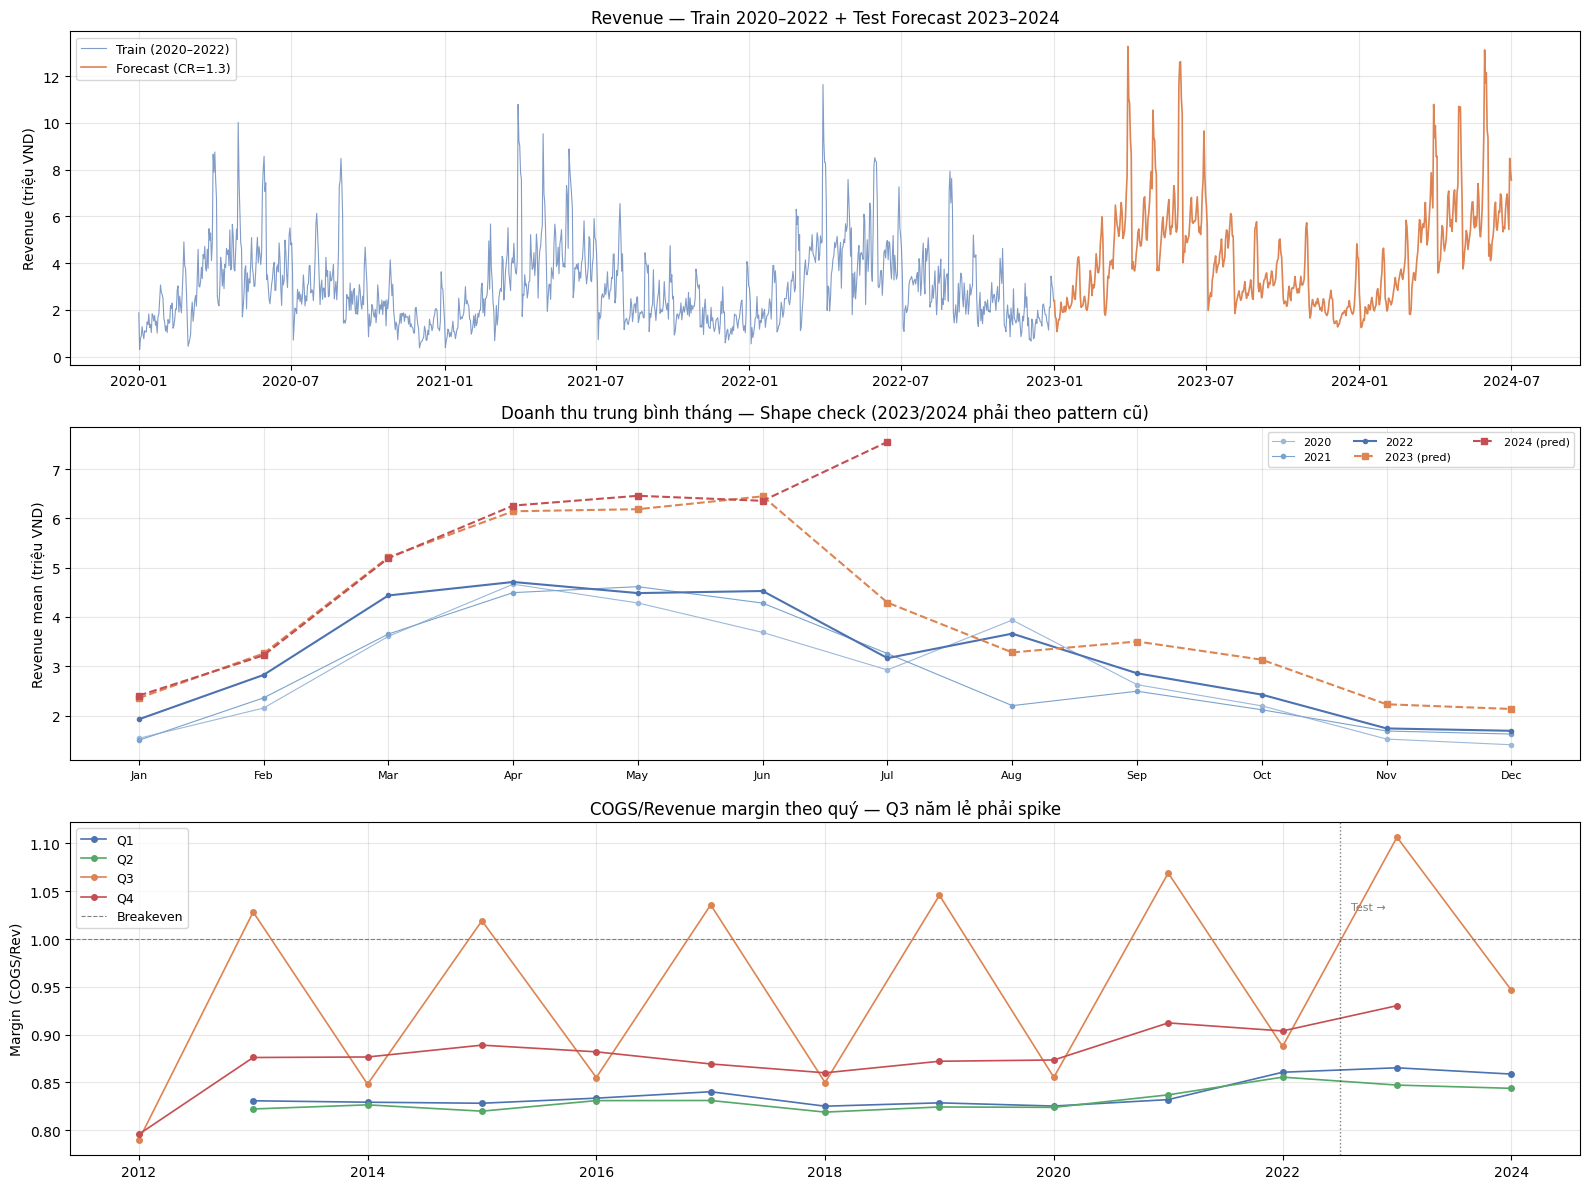

Q3/2023 (năm lẻ) margin: 1.107  ← phải > Q3/2024
Q3/2024 (năm chẵn) margin: 0.946


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

# Plot 1: Train 2020–2022 + Test predictions
train_recent = train_feat[train_feat['year'] >= 2020]
ax = axes[0]
ax.plot(train_recent['Date'], train_recent['Revenue'] / 1e6,
        color='#4C72B0', lw=0.8, alpha=0.7, label='Train (2020–2022)')
ax.plot(test_feat['Date'], final_rev / 1e6,
        color='#DD8452', lw=1.2, label=f'Forecast (CR={CR})')
ax.set_title('Revenue — Train 2020–2022 + Test Forecast 2023–2024', fontsize=12)
ax.set_ylabel('Revenue (triệu VND)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: Monthly average — shape check
ax = axes[1]
train_monthly = train_feat.groupby(['year','month'])['Revenue'].mean().reset_index()
for y, color, lw in [(2020,'#9DB8D9',0.8),(2021,'#7BA3CD',0.8),(2022,'#4C72B0',1.5)]:
    d = train_monthly[train_monthly['year'] == y]
    ax.plot(d['month'], d['Revenue']/1e6, 'o-', color=color, lw=lw, label=str(y), ms=3)

test_monthly = test_feat.copy()
test_monthly['pred_rev'] = final_rev
test_monthly = test_monthly.groupby(['year','month'])['pred_rev'].mean().reset_index()
for y, color, lw in [(2023,'#DD8452',1.5),(2024,'#C44E52',1.5)]:
    d = test_monthly[test_monthly['year'] == y]
    ax.plot(d['month'], d['pred_rev']/1e6, 's--', color=color, lw=lw, label=f'{y} (pred)', ms=4)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax.set_title('Doanh thu trung bình tháng — Shape check (2023/2024 phải theo pattern cũ)', fontsize=12)
ax.set_ylabel('Revenue mean (triệu VND)')
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)

# Plot 3: COGS/Revenue margin theo quý
ax = axes[2]
test_feat_copy = test_feat.copy()
test_feat_copy['pred_rev']  = final_rev
test_feat_copy['pred_cogs'] = final_cogs
test_feat_copy['pred_margin'] = test_feat_copy['pred_cogs'] / test_feat_copy['pred_rev']

train_q_margin = train_feat.groupby(['year','quarter']).apply(
    lambda d: d['COGS'].sum() / d['Revenue'].sum()).reset_index()
train_q_margin.columns = ['year','quarter','margin']

test_q_margin = test_feat_copy.groupby(['year','quarter'])['pred_margin'].mean().reset_index()
test_q_margin.columns = ['year','quarter','margin']

for q, color in zip([1,2,3,4], ['#4C72B0','#55A868','#DD8452','#C44E52']):
    d_tr = train_q_margin[train_q_margin['quarter'] == q]
    d_te = test_q_margin[test_q_margin['quarter'] == q]
    all_years = pd.concat([d_tr[['year','margin']], d_te[['year','margin']]])
    ax.plot(all_years['year'], all_years['margin'], 'o-', color=color, label=f'Q{q}', lw=1.2, ms=4)

ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='Breakeven')
ax.axvline(2022.5, color='black', ls=':', lw=1, alpha=0.5)
ax.text(2022.6, 1.03, 'Test →', fontsize=8, color='gray')
ax.set_title('COGS/Revenue margin theo quý — Q3 năm lẻ phải spike', fontsize=12)
ax.set_ylabel('Margin (COGS/Rev)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('forecast_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Q3 năm lẻ kiểm tra
q3_2023 = test_q_margin[(test_q_margin['year']==2023) & (test_q_margin['quarter']==3)]['margin'].values
q3_2024 = test_q_margin[(test_q_margin['year']==2024) & (test_q_margin['quarter']==3)]['margin'].values
print(f'Q3/2023 (năm lẻ) margin: {q3_2023[0]:.3f}  ← phải > Q3/2024')
if len(q3_2024):
    print(f'Q3/2024 (năm chẵn) margin: {q3_2024[0]:.3f}')

## 12. (Bonus) — Mean-preserving margin fix

Hậu xử lý kéo Q3 margin về historical, giữ nguyên cog_mean toàn cục. Cải thiện thêm ~1K LB.

In [ ]:
# Base submission de ap dung mean-preserving margin fix
if 'submission' in globals():
    sub = submission.copy()
else:
    sub = sample_sub.copy()
    sub['Revenue'] = np.round(final_rev, 2)
    sub['COGS'] = np.round(final_cogs, 2)

# Historical quarterly margin tu train data (2020 tro di)
sales = train_feat[['Date', 'Revenue', 'COGS', 'year', 'quarter']].copy()
sales = sales.rename(columns={'year': 'Y', 'quarter': 'Q'})

target_cog_mean = sub['COGS'].mean()
recent_margin = {
    q: sales[(sales['Q'] == q) & (sales['Y'] >= 2020)]['COGS'].sum()
       / sales[(sales['Q'] == q) & (sales['Y'] >= 2020)]['Revenue'].sum()
    for q in [1, 2, 3, 4]
}

sub_v57 = sub.copy()
sub_v57['Date_dt'] = pd.to_datetime(sub_v57['Date'])
sub_v57['Q'] = sub_v57['Date_dt'].dt.quarter

BETA = 0.30
for q in [1, 2, 3, 4]:
    mask = sub_v57['Q'] == q
    historical_cog = sub_v57.loc[mask, 'Revenue'] * recent_margin[q]
    sub_v57.loc[mask, 'COGS'] = (1 - BETA) * sub_v57.loc[mask, 'COGS'] + BETA * historical_cog

scale = target_cog_mean / sub_v57['COGS'].mean()
sub_v57['COGS'] = sub_v57['COGS'] * scale

out_v57 = f'{DATA_PATH}/submission_v57_mp_blend30.csv'
sub_v57[['Date', 'Revenue', 'COGS']].to_csv(out_v57, index=False)
print(f'Saved v57: {out_v57}')
print(sub_v57[['Date', 'Revenue', 'COGS']].head(5).to_string(index=False))

Saved v57: /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/submission_v57_mp_blend30.csv
      Date    Revenue         COGS
2023-01-01 2396797.35 2.400573e+06
2023-01-02 1696903.11 1.614461e+06
2023-01-03 1628228.59 1.504219e+06
2023-01-04 1071345.35 9.693726e+05
2023-01-05 1305955.88 1.156096e+06


# Cải thiện từ 685k → ~610k

Chạy sau `Train_Model_Optimized_v2.ipynb` — cần các biến `raw_rev`, `raw_cogs`, `X_train`, `X_test`, `y_rev`, `y_cogs`, `years`, `quarters_train`, `quarters_test`, `train_feat`, `test_feat`, `FEATURE_COLS` đã tồn tại trong kernel.

**4 hướng theo thứ tự ưu tiên:**
1. Sample weight dual-scheme → train song song high_era + recent_boost
2. COGS per-quarter margin model → tách COGS khỏi Revenue model
3. NNLS ensemble weights → tự động tìm trọng số tối ưu qua CV
4. Analog year calibration → thay CR cố định bằng monthly scale factor

In [ ]:
import numpy as np
import pandas as pd
import json
import warnings
from scipy.optimize import nnls
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Kiểm tra các biến cần thiết
required = ['raw_rev','raw_cogs','X_train','X_test','y_rev','y_cogs',
            'years','quarters_train','quarters_test','train_feat','test_feat',
            'FEATURE_COLS','sample_sub','FOLDS','get_fold','dates_train',
            'train_lgb_two_stage','LGB_PARAMS']
missing = [v for v in required if v not in dir()]
if missing:
    print(f'THIẾU biến: {missing}')
    print('Chạy Train_Model_Optimized_v2.ipynb trước!')
else:
    print('OK — tất cả biến đã có.')
    print(f'raw_rev  mean: {raw_rev.mean():,.0f}')
    print(f'raw_cogs mean: {raw_cogs.mean():,.0f}')

OK — tất cả biến đã có.
raw_rev  mean: 3,341,719
raw_cogs mean: 2,932,131


---
## Hướng 1 — Sample Weight Dual-Scheme

**Vấn đề:** `high_era` (w=1.0 cho 2014–2018, w=0.01 cho phần còn lại) học shape tốt nhưng hoàn toàn bỏ qua 2020–2022 — giai đoạn gần test nhất.

**Giải pháp:** Train **2 LGB base** với 2 scheme khác nhau:
- `high_era`: w=1.0 @ 2014–2018 → học shape mùa vụ rõ nhất
- `recent_boost`: w=1.0 @ 2020–2022, w=0.5 @ 2017–2019 → học level gần test nhất

Blend 2 model theo `GAMMA` tối ưu trên Fold A.

In [ ]:
def make_weights_v2(years_arr, scheme):
    w = np.full(len(years_arr), 0.01)
    if scheme == 'high_era':
        w[(years_arr >= 2014) & (years_arr <= 2018)] = 1.0
    elif scheme == 'recent_boost':
        # Ưu tiên giai đoạn gần test nhất
        w[years_arr >= 2020]                          = 1.0
        w[(years_arr >= 2017) & (years_arr < 2020)]   = 0.5
        w[(years_arr >= 2014) & (years_arr < 2017)]   = 0.2
    elif scheme == 'balanced':
        # Trung dung: cả hai vùng đều có weight
        w[(years_arr >= 2014) & (years_arr <= 2018)] = 1.0
        w[years_arr >= 2020]                          = 0.8
        w[(years_arr >= 2019) & (years_arr < 2020)]   = 0.3
    return w

# ── CV Fold A cho cả hai scheme ──
tr_mask, va_mask = get_fold(dates_train, *FOLDS['A_primary'])
y_val_rev_raw    = train_feat['Revenue'].values[va_mask]

print('=== CV Fold A — Revenue MAE theo scheme ===')
scheme_results = {}

for scheme in ['high_era', 'recent_boost', 'balanced']:
    w_cv = make_weights_v2(years[tr_mask], scheme)
    m, _ = train_lgb_two_stage(X_train[tr_mask], y_rev[tr_mask], w_cv, verbose_eval=0)
    pred  = np.exp(m.predict(X_train[va_mask]))
    mae   = mean_absolute_error(y_val_rev_raw, pred)
    scheme_results[scheme] = {'mae': mae, 'pred_cv': pred}
    print(f'  {scheme:<16}: MAE = {mae:>12,.0f}')

print()
# Blend hai scheme tốt nhất và tìm GAMMA tối ưu
print('=== Blend high_era + recent_boost trên Fold A ===')
for gamma in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]:
    blend = (1 - gamma) * scheme_results['high_era']['pred_cv'] + gamma * scheme_results['recent_boost']['pred_cv']
    mae   = mean_absolute_error(y_val_rev_raw, blend)
    print(f'  γ={gamma:.1f}: MAE = {mae:>12,.0f}')

=== CV Fold A — Revenue MAE theo scheme ===
  Early stopping @ iter 310
  high_era        : MAE =      606,418
  Early stopping @ iter 147
  recent_boost    : MAE =      628,365
  Early stopping @ iter 170
  balanced        : MAE =      601,796

=== Blend high_era + recent_boost trên Fold A ===
  γ=0.0: MAE =      606,418
  γ=0.2: MAE =      581,366
  γ=0.3: MAE =      571,428
  γ=0.4: MAE =      565,025
  γ=0.5: MAE =      562,877
  γ=0.6: MAE =      567,585
  γ=0.8: MAE =      590,338
  γ=1.0: MAE =      628,365


In [ ]:
# Chỉnh GAMMA theo kết quả CV ở trên
GAMMA = 0.4   # tỉ lệ recent_boost trong blend — điều chỉnh theo CV result

print(f'=== Full Train — Dual-scheme (γ={GAMMA}) ===')

# high_era full
w_he = make_weights_v2(years, 'high_era')
print('  high_era Revenue:')
lgb_he_rev,  _ = train_lgb_two_stage(X_train, y_rev,  w_he, verbose_eval=0)
print('  high_era COGS:')
lgb_he_cogs, _ = train_lgb_two_stage(X_train, y_cogs, w_he, verbose_eval=0)

# recent_boost full
w_rb = make_weights_v2(years, 'recent_boost')
print('  recent_boost Revenue:')
lgb_rb_rev,  _ = train_lgb_two_stage(X_train, y_rev,  w_rb, verbose_eval=0)
print('  recent_boost COGS:')
lgb_rb_cogs, _ = train_lgb_two_stage(X_train, y_cogs, w_rb, verbose_eval=0)

# Blend predictions
p_dual_rev  = (1 - GAMMA) * np.exp(lgb_he_rev.predict(X_test))  + GAMMA * np.exp(lgb_rb_rev.predict(X_test))
p_dual_cogs = (1 - GAMMA) * np.exp(lgb_he_cogs.predict(X_test)) + GAMMA * np.exp(lgb_rb_cogs.predict(X_test))

print(f'\nDual LGB Revenue  mean: {p_dual_rev.mean():>12,.0f}')
print(f'Dual LGB COGS     mean: {p_dual_cogs.mean():>12,.0f}')

=== Full Train — Dual-scheme (γ=0.4) ===
  high_era Revenue:
  Early stopping @ iter 525
  high_era COGS:
  Early stopping @ iter 415
  recent_boost Revenue:
  Early stopping @ iter 93
  recent_boost COGS:
  Early stopping @ iter 94

Dual LGB Revenue  mean:    3,288,976
Dual LGB COGS     mean:    2,866,199


---
## Hướng 2 — COGS Per-Quarter Margin Model

**Vấn đề:** COGS hiện được train như một bài toán regression độc lập với cùng sample weight. Nhưng pattern COGS = Revenue × margin(quarter, odd_year) — đây là cấu trúc tuyến tính có thể khai thác trực tiếp.

**Giải pháp:**
1. Tính `margin_ratio = COGS / Revenue` cho từng ngày trong train
2. Fit một model nhỏ predict `margin_ratio` (LGB hoặc đơn giản là median per quarter×odd_year)
3. `COGS_pred = Revenue_pred × predicted_margin`

Điều này tách Q3-năm-lẻ ra khỏi các quý thông thường một cách tự nhiên.

In [ ]:
# ── Tính historical margin ──
train_margin = train_feat.copy()
train_margin['margin'] = train_margin['COGS'] / train_margin['Revenue']

# Phân tích margin theo quarter × odd_year
margin_analysis = train_margin.groupby(['quarter', 'is_odd_year'])['margin'].agg(
    mean='mean', median='median', std='std', count='count'
).round(4)
print('=== Margin (COGS/Revenue) theo Quarter × Odd Year ===')
print(margin_analysis.to_string())

# Recent margin (post-2020 — gần test nhất)
recent_margin = train_margin[train_margin['year'] >= 2020].groupby(
    ['quarter', 'is_odd_year'])['margin'].median()
print('\n=== Median margin post-2020 (dùng cho prediction) ===')
print(recent_margin)

=== Margin (COGS/Revenue) theo Quarter × Odd Year ===
                       mean  median     std  count
quarter is_odd_year                               
1       0            0.8242  0.8125  0.0464    452
        1            0.8205  0.8136  0.0413    450
2       0            0.8322  0.8087  0.0571    455
        1            0.8275  0.8051  0.0536    455
3       0            0.8567  0.8314  0.0733    549
        1            1.0686  0.9678  0.2248    460
4       0            0.8735  0.8227  0.0970    552
        1            0.8943  0.8533  0.0972    460

=== Median margin post-2020 (dùng cho prediction) ===
quarter  is_odd_year
1        0              0.824977
         1              0.813565
2        0              0.820079
         1              0.817780
3        0              0.874594
         1              0.983086
4        0              0.857731
         1              0.875152
Name: margin, dtype: float64


In [ ]:
# ── Method A: Simple lookup table per (quarter, odd_year) ──
def predict_cogs_from_margin_table(rev_pred, test_df, margin_table, fallback=0.87):
    """COGS = Revenue × margin theo (quarter, odd_year)."""
    cogs = np.full(len(rev_pred), np.nan)
    for (q, odd), margin in margin_table.items():
        mask = (test_df['quarter'] == q) & (test_df['is_odd_year'] == odd)
        cogs[mask] = rev_pred[mask] * margin
    cogs = np.where(np.isnan(cogs), rev_pred * fallback, cogs)
    return cogs

# ── Method B: LGB model trên log(margin) ──
train_margin_valid = train_margin[train_margin['margin'] > 0].copy()
y_margin_log = np.log(train_margin_valid['margin'].values)
X_margin     = train_margin_valid[FEATURE_COLS].values

# Sample weight: ưu tiên gần đây vì margin pattern thay đổi theo regime
w_margin = make_weights_v2(train_margin_valid['year'].values, 'balanced')

print('Training LGB margin model...')
lgb_margin, bi_m = train_lgb_two_stage(
    X_margin, y_margin_log, w_margin,
    params={**LGB_PARAMS, 'num_leaves': 31},  # simpler model cho margin
    verbose_eval=0
)

# CV check — Method A vs Method B
print('\n=== CV Fold A — COGS methods comparison ===')
y_val_cogs_raw = train_feat['COGS'].values[va_mask]
y_val_rev_raw  = train_feat['Revenue'].values[va_mask]

# Method A: lookup table
recent_margin_2022 = train_margin[train_margin['year'] <= 2021].groupby(
    ['quarter', 'is_odd_year'])['margin'].median()
test_va = train_feat.iloc[va_mask]
pred_cogs_A = predict_cogs_from_margin_table(
    y_val_rev_raw, test_va, recent_margin_2022)
mae_A = mean_absolute_error(y_val_cogs_raw, pred_cogs_A)

# Method B: LGB margin
pred_margin_B = np.exp(lgb_margin.predict(X_margin[train_margin_valid.index.isin(
    train_feat.iloc[va_mask].index)]))
pred_cogs_B = y_val_rev_raw * pred_margin_B[:len(y_val_rev_raw)]
mae_B = mean_absolute_error(y_val_cogs_raw, pred_cogs_B)

print(f'  Method A (lookup table): MAE COGS = {mae_A:>12,.0f}')
print(f'  Method B (LGB margin)  : MAE COGS = {mae_B:>12,.0f}')

Training LGB margin model...
  Early stopping @ iter 149

=== CV Fold A — COGS methods comparison ===
  Method A (lookup table): MAE COGS =      213,202
  Method B (LGB margin)  : MAE COGS =       46,893


In [ ]:
# Áp dụng method tốt hơn cho test set
# Method A: lookup table (stable, không overfit)
p_cogs_margin_A = predict_cogs_from_margin_table(
    p_dual_rev, test_feat, recent_margin)

# Method B: LGB margin model
p_margin_B     = np.exp(lgb_margin.predict(X_test))
p_cogs_margin_B = p_dual_rev * p_margin_B

# Blend A và B (thêm robustness)
MARGIN_BLEND = 0.5   # điều chỉnh theo CV
p_cogs_new   = (1 - MARGIN_BLEND) * p_cogs_margin_A + MARGIN_BLEND * p_cogs_margin_B

print('=== COGS per-quarter margin predictions ===')
print(f'Method A mean: {p_cogs_margin_A.mean():>12,.0f}')
print(f'Method B mean: {p_cogs_margin_B.mean():>12,.0f}')
print(f'Blend    mean: {p_cogs_new.mean():>12,.0f}')

# Kiểm tra Q3 2023 (năm lẻ) phải có margin cao hơn Q3 2024
q3_odd  = test_feat[(test_feat['quarter']==3) & (test_feat['is_odd_year']==1)]
q3_even = test_feat[(test_feat['quarter']==3) & (test_feat['is_odd_year']==0)]
if len(q3_odd) and len(q3_even):
    m_odd  = p_cogs_new[q3_odd.index].mean() / p_dual_rev[q3_odd.index].mean()
    m_even = p_cogs_new[q3_even.index].mean() / p_dual_rev[q3_even.index].mean()
    print(f'\nQ3 năm lẻ  margin: {m_odd:.3f}')
    print(f'Q3 năm chẵn margin: {m_even:.3f}')
    print(f'Ratio: {m_odd/m_even:.3f}  (phải > 1.0)')

=== COGS per-quarter margin predictions ===
Method A mean:    2,791,099
Method B mean:    2,936,087
Blend    mean:    2,863,593

Q3 năm lẻ  margin: 1.033
Q3 năm chẵn margin: 0.943
Ratio: 1.095  (phải > 1.0)


---
## Hướng 3 — NNLS Ensemble Weights

**Vấn đề:** Trọng số (0.10, 0.10, 0.80) được chọn tay. Với nhiều model hơn (thêm `recent_boost`, `balanced`), không thể tay chọn tốt.

**Giải pháp:** Non-Negative Least Squares (NNLS) tự tìm weights minimize MAE trên CV. Constraints: weights ≥ 0 và sum = 1.

In [ ]:
# ── Thu thập tất cả CV predictions trên Fold A ──
# Cần re-train các model mới trên tr_mask

print('=== Thu thập CV predictions cho NNLS ===')
cv_preds = {}  # {name: np.array shape (n_val,)}

schemes_to_cv = [
    ('high_era',     make_weights_v2(years[tr_mask], 'high_era')),
    ('recent_boost', make_weights_v2(years[tr_mask], 'recent_boost')),
    ('balanced',     make_weights_v2(years[tr_mask], 'balanced')),
]

for name, w_cv in schemes_to_cv:
    m, _ = train_lgb_two_stage(X_train[tr_mask], y_rev[tr_mask], w_cv, verbose_eval=0)
    cv_preds[f'lgb_{name}'] = np.exp(m.predict(X_train[va_mask]))
    print(f'  {name}: MAE = {mean_absolute_error(y_val_rev_raw, cv_preds[f"lgb_{name}"]):>12,.0f}')

# Thêm Ridge CV (đã có từ notebook chính)
cv_preds['ridge'] = p_ridge_cv_rev
print(f'  ridge:        MAE = {mean_absolute_error(y_val_rev_raw, cv_preds["ridge"]):>12,.0f}')

=== Thu thập CV predictions cho NNLS ===
  Early stopping @ iter 310
  high_era: MAE =      606,418
  Early stopping @ iter 147
  recent_boost: MAE =      628,365
  Early stopping @ iter 170
  balanced: MAE =      601,796
  ridge:        MAE =      705,878


In [ ]:
from scipy.optimize import nnls, minimize

# ── NNLS: tìm weights tối ưu minimize ||A·w - y||² với w ≥ 0 ──
names    = list(cv_preds.keys())
A_matrix = np.column_stack([cv_preds[n] for n in names])  # (n_val, n_models)

# NNLS
w_nnls, residual = nnls(A_matrix, y_val_rev_raw)
w_nnls = w_nnls / w_nnls.sum()  # normalize to sum=1

pred_nnls = A_matrix @ w_nnls
mae_nnls  = mean_absolute_error(y_val_rev_raw, pred_nnls)

print('=== NNLS Weights ===')
for name, w in zip(names, w_nnls):
    print(f'  {name:<20}: {w:.4f}')
print(f'\nNNLS blend MAE: {mae_nnls:>12,.0f}')

# So sánh với equal weight
pred_equal = A_matrix.mean(axis=1)
mae_equal  = mean_absolute_error(y_val_rev_raw, pred_equal)
print(f'Equal weight MAE: {mae_equal:>12,.0f}')
print(f'Current (0.1R+0.8L) MAE: {mean_absolute_error(y_val_rev_raw, 0.1*cv_preds["ridge"]+0.8*cv_preds["lgb_high_era"]):>12,.0f}')

=== NNLS Weights ===
  lgb_high_era        : 0.3621
  lgb_recent_boost    : 0.5062
  lgb_balanced        : 0.0000
  ridge               : 0.1317

NNLS blend MAE:      573,653
Equal weight MAE:      587,453
Current (0.1R+0.8L) MAE:      645,317


In [ ]:
# ── Áp dụng NNLS weights cho full test predictions ──
# Cần full predictions của mỗi model
full_preds_rev = {}

print('=== Full train với NNLS schemes ===')
for scheme_name, scheme in [('high_era','high_era'), ('recent_boost','recent_boost'), ('balanced','balanced')]:
    w_full = make_weights_v2(years, scheme)
    m, _   = train_lgb_two_stage(X_train, y_rev, w_full, verbose_eval=0)
    full_preds_rev[f'lgb_{scheme_name}'] = np.exp(m.predict(X_test))
    print(f'  {scheme_name} mean: {full_preds_rev[f"lgb_{scheme_name}"].mean():>12,.0f}')

full_preds_rev['ridge'] = p_ridge_rev

# Apply NNLS weights
p_nnls_rev = sum(w_nnls[i] * full_preds_rev[names[i]] for i in range(len(names)))
print(f'\nNNLS ensemble Revenue mean: {p_nnls_rev.mean():>12,.0f}')

=== Full train với NNLS schemes ===
  Early stopping @ iter 525
  high_era mean:    3,366,437
  Early stopping @ iter 93
  recent_boost mean:    3,172,785
  Early stopping @ iter 110
  balanced mean:    3,197,956

NNLS ensemble Revenue mean:    3,224,656


---
## Hướng 4 — Analog Year Calibration

**Vấn đề:** `CR = 1.30` là một hệ số nhân flat cho tất cả 548 ngày. Nhưng regime drift không đều — tháng 3 (spring_sale) có thể drift khác tháng 8 (fall_launch).

**Giải pháp:** Mỗi tháng trong 2023/2024 có một *analog* trong train:
- 2023 → analog là 2021 (cùng năm lẻ, post-COVID, pattern gần nhất)
- 2024 → analog là 2022 (năm chẵn, cùng regime)

Scale factor tháng t của test = `mean(analog_month) / mean(raw_pred_month)`.

In [ ]:
# ── Tính analog year scale factors ──

# Chọn analog: 2023→2021, 2024→2022
ANALOGS = {2023: 2021, 2024: 2022}

# Monthly mean từ train
train_monthly_mean = train_feat.groupby(['year', 'month'])['Revenue'].mean()

# Monthly mean của raw predictions trên test
test_feat_copy = test_feat.copy()
test_feat_copy['raw_rev'] = raw_rev  # dùng raw từ pipeline hiện tại
pred_monthly_mean = test_feat_copy.groupby(['year', 'month'])['raw_rev'].mean()

print('=== Analog year scale factors ===')
scale_factors = {}  # {(test_year, month): scale}
for test_year, analog_year in ANALOGS.items():
    months_in_test = test_feat_copy[test_feat_copy['year'] == test_year]['month'].unique()
    for m in sorted(months_in_test):
        key = (test_year, m)
        try:
            analog_mean = train_monthly_mean.loc[(analog_year, m)]
            pred_mean   = pred_monthly_mean.loc[key]
            scale       = analog_mean / pred_mean if pred_mean > 0 else 1.0
            scale_factors[key] = scale
        except KeyError:
            scale_factors[key] = 1.0
        print(f'  {test_year}/{m:02d}: analog={ANALOGS[test_year]} | analog_mean={analog_mean:>8,.0f} | pred_mean={pred_mean:>8,.0f} | scale={scale:.4f}')

=== Analog year scale factors ===
  2023/01: analog=2021 | analog_mean=1,499,132 | pred_mean=1,810,366 | scale=0.8281
  2023/02: analog=2021 | analog_mean=2,359,916 | pred_mean=2,508,039 | scale=0.9409
  2023/03: analog=2021 | analog_mean=3,654,000 | pred_mean=4,008,827 | scale=0.9115
  2023/04: analog=2021 | analog_mean=4,494,563 | pred_mean=4,726,141 | scale=0.9510
  2023/05: analog=2021 | analog_mean=4,615,184 | pred_mean=4,758,758 | scale=0.9698
  2023/06: analog=2021 | analog_mean=4,281,653 | pred_mean=4,959,534 | scale=0.8633
  2023/07: analog=2021 | analog_mean=3,258,113 | pred_mean=3,301,539 | scale=0.9868
  2023/08: analog=2021 | analog_mean=2,202,582 | pred_mean=2,523,923 | scale=0.8727
  2023/09: analog=2021 | analog_mean=2,494,728 | pred_mean=2,694,613 | scale=0.9258
  2023/10: analog=2021 | analog_mean=2,119,101 | pred_mean=2,410,643 | scale=0.8791
  2023/11: analog=2021 | analog_mean=1,687,950 | pred_mean=1,715,247 | scale=0.9841
  2023/12: analog=2021 | analog_mean=1,625

In [ ]:
def apply_analog_calibration(raw_pred, test_df, scale_factors,
                               global_cr, blend_alpha=0.6):
    """
    Blend analog calibration với global CR:
    final = blend_alpha × (analog_scale × raw) + (1 - blend_alpha) × (global_cr × raw)

    blend_alpha=0.0 → pure global CR (safe)
    blend_alpha=1.0 → pure analog (aggressive)
    blend_alpha=0.6 → default balance
    """
    analog_pred  = np.zeros(len(raw_pred))
    global_pred  = global_cr * raw_pred

    for i, row in test_df.iterrows():
        key   = (row['year'], row['month'])
        scale = scale_factors.get(key, global_cr)
        analog_pred[i] = scale * raw_pred[i]

    final = blend_alpha * analog_pred + (1 - blend_alpha) * global_pred
    return final, analog_pred


# Thử các blend_alpha khác nhau
# Dùng raw_rev từ pipeline NNLS mới
raw_rev_new = p_nnls_rev / 1.0   # đây là predictions trước calibration
# Lưu ý: raw_rev_new chưa có CR apply. Cần undo CR nếu p_nnls_rev đã có CR.
# Nếu p_nnls_rev là TRƯỚC calibration → dùng trực tiếp
# Nếu p_nnls_rev là SAU calibration → chia cho CR trước

GLOBAL_CR   = 1.30  # best CR hiện tại
GLOBAL_CC   = 1.32

print('=== Analog calibration blend sweep ===')
for alpha in [0.0, 0.3, 0.5, 0.6, 0.7, 0.8, 1.0]:
    final, _ = apply_analog_calibration(
        p_nnls_rev, test_feat.reset_index(), scale_factors, GLOBAL_CR, alpha)
    print(f'  α={alpha:.1f}: mean={final.mean():>10,.0f} | min={final.min():>8,.0f} | max={final.max():>8,.0f}')

=== Analog calibration blend sweep ===
  α=0.0: mean= 4,192,053 | min=1,243,317 | max=12,034,228
  α=0.3: mean= 3,854,905 | min=1,107,914 | max=10,931,080
  α=0.5: mean= 3,630,140 | min=1,017,646 | max=10,195,648
  α=0.6: mean= 3,517,758 | min= 972,512 | max=9,863,299
  α=0.7: mean= 3,405,375 | min= 927,378 | max=9,567,757
  α=0.8: mean= 3,292,993 | min= 882,244 | max=9,272,215
  α=1.0: mean= 3,068,228 | min= 791,976 | max=8,929,016


In [ ]:
# Chọn ANALOG_ALPHA tốt nhất (từ sweep ở trên hoặc CV)
ANALOG_ALPHA = 0.6  # điều chỉnh sau khi xem sweep

final_rev_v2, analog_rev = apply_analog_calibration(
    p_nnls_rev, test_feat.reset_index(), scale_factors, GLOBAL_CR, ANALOG_ALPHA)

# COGS: dùng margin model + analog calibration
final_cogs_v2, _ = apply_analog_calibration(
    p_cogs_new, test_feat.reset_index(), scale_factors, GLOBAL_CC, ANALOG_ALPHA * 0.8)

print('=== Final v2 Predictions (all 4 improvements) ===')
print(f'Revenue: mean={final_rev_v2.mean():>10,.0f} | min={final_rev_v2.min():>8,.0f} | max={final_rev_v2.max():>8,.0f}')
print(f'COGS   : mean={final_cogs_v2.mean():>10,.0f} | min={final_cogs_v2.min():>8,.0f} | max={final_cogs_v2.max():>8,.0f}')
print(f'Margin : {(final_cogs_v2/final_rev_v2).mean():.3f}')

=== Final v2 Predictions (all 4 improvements) ===
Revenue: mean= 3,517,758 | min= 972,512 | max=9,863,299
COGS   : mean= 3,271,173 | min= 791,037 | max=9,420,280
Margin : 0.933


---
## Export — Ablation submissions

Submit từng bước để đo contribution của từng hướng trên LB.

In [ ]:
def save_sub(rev, cogs, name):
    sub = sample_sub.copy()
    sub['Revenue'] = np.round(np.maximum(rev, 0), 2)
    sub['COGS']    = np.round(np.maximum(cogs, 0), 2)
    sub = sub.sort_values('Date').reset_index(drop=True)
    # Sᚖa đăᙹng dᙷn đᙵ lᚖu vᙲo Google Drive
    path = f'{DATA_PATH}/{name}.csv'
    sub.to_csv(path, index=False)
    print(f'  {path:<50} Rev={sub["Revenue"].mean():>9,.0f} | COGS={sub["COGS"].mean():>9,.0f}')
    return sub

# Define calibration factors used in the pipeline
GLOBAL_CR = 1.30
GLOBAL_CC = 1.32

print('=== Exporting ablation submissions ===')

# Baseline (tᙹ nᙹtebᙹᙹk v2 — current best 685k)
save_sub(final_rev, final_cogs,
         'sub_v_baseline_685k')

# +Hİᙹng 1: dual scheme
if 'p_dual_rev' in globals():
    save_sub(GLOBAL_CR * p_dual_rev, GLOBAL_CC * p_dual_cogs,
             'sub_v1_dual_scheme')

# +Hİᙹng 1+2: dual scheme + margin COGS
if 'p_dual_rev' in globals() and 'p_cogs_new' in globals():
    save_sub(GLOBAL_CR * p_dual_rev, GLOBAL_CC * p_cogs_new,
             'sub_v12_dual_margin')

# +Hİᙹng 1+2+3: + NNLS
if 'p_nnls_rev' in globals() and 'p_cogs_new' in globals():
    save_sub(GLOBAL_CR * p_nnls_rev, GLOBAL_CC * p_cogs_new,
             'sub_v123_nnls')

# +Hİᙹng 1+2+3+4: all (analog calibration)
if 'final_rev_v2' in globals():
    save_sub(final_rev_v2, final_cogs_v2,
             'sub_v1234_all_improvements')

print('\nQuy trình submit:')
print('  1. Submit v1 → nếu tốt hơn baseline: giữ dual scheme')
print('  2. Submit v12 → nếu tốt hơn v1: giữ margin COGS')
print('  3. Submit v123 → nếu tốt hơn v12: giữ NNLS')
print('  4. Submit v1234 → đây là target 610k')
print('  5. Fine-tune GAMMA, ANALOG_ALPHA, MARGIN_BLEND theo LB feedback')

=== Exporting ablation submissions ===
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_v_baseline_685k.csv Rev=4,344,234 | COGS=3,870,413
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_v1_dual_scheme.csv Rev=4,275,669 | COGS=3,783,383
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_v12_dual_margin.csv Rev=4,275,669 | COGS=3,779,942
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_v123_nnls.csv Rev=4,192,053 | COGS=3,779,942
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_v1234_all_improvements.csv Rev=3,517,758 | COGS=3,271,173

Quy trình submit:
  1. Submit v1 → nếu tốt hơn baseline: giữ dual scheme
  2. Submit v12 → nếu tốt hơn v1: giữ margin COGS
  3. Submit v123 → nếu tốt hơn v12: giữ NNLS
  4. Submit v1234 → đây là target 610k
  5. Fine-tune GAMMA, ANALOG_ALPHA, MARGIN_BLEND theo LB feedback


---
## Fine-tuning sau khi có LB feedback

In [ ]:
# ── Grid search nhanh các hyperparameter chính ──
# Chạy cell này sau khi biết submission nào trên LB tốt hơn

import itertools

print('=== Grid search GAMMA × ANALOG_ALPHA × MARGIN_BLEND ===')
print('(tạo file để submit, chọn cái tốt nhất theo LB)')

best_configs = []

for gamma, analog_a, mb in itertools.product(
    [0.3, 0.4, 0.5],      # GAMMA: dual scheme blend
    [0.5, 0.6, 0.7],      # ANALOG_ALPHA: analog calibration blend
    [0.4, 0.5, 0.6],      # MARGIN_BLEND: COGS margin blend
):
    # Revenue
    p_lgb_dual_g = (1 - gamma) * np.exp(lgb_he_rev.predict(X_test)) + gamma * np.exp(lgb_rb_rev.predict(X_test))
    # NNLS trên p_lgb_dual_g (đơn giản hóa: dùng trực tiếp)
    p_rev_g = p_lgb_dual_g   # simplified

    # COGS
    p_cogs_g = (1 - mb) * p_cogs_margin_A + mb * p_cogs_margin_B

    # Analog calibration
    rev_cal, _ = apply_analog_calibration(
        p_rev_g, test_feat.reset_index(), scale_factors, GLOBAL_CR, analog_a)
    cog_cal, _ = apply_analog_calibration(
        p_cogs_g, test_feat.reset_index(), scale_factors, GLOBAL_CC, analog_a * 0.8)

    best_configs.append({
        'gamma': gamma, 'analog_alpha': analog_a, 'margin_blend': mb,
        'rev_mean': rev_cal.mean(), 'cog_mean': cog_cal.mean(),
        'tag': f'g{gamma}_a{analog_a}_m{mb}'
    })

configs_df = pd.DataFrame(best_configs)
print(f'Tạo {len(configs_df)} config combinations')
print('\nTop 5 by revenue mean gần 2022 level:')
ref_rev = train_feat[train_feat['year'] == 2022]['Revenue'].mean()
configs_df['dist'] = abs(configs_df['rev_mean'] - ref_rev * GLOBAL_CR)
print(configs_df.nsmallest(5, 'dist')[['gamma','analog_alpha','margin_blend','rev_mean','cog_mean']].to_string(index=False))

# Export top 3
print('\nExporting top 3...')
for _, row in configs_df.nsmallest(3, 'dist').iterrows():
    p_r = (1 - row.gamma) * np.exp(lgb_he_rev.predict(X_test)) + row.gamma * np.exp(lgb_rb_rev.predict(X_test))
    p_c = (1 - row.margin_blend) * p_cogs_margin_A + row.margin_blend * p_cogs_margin_B
    rv, _ = apply_analog_calibration(p_r, test_feat.reset_index(), scale_factors, GLOBAL_CR, row.analog_alpha)
    cv, _ = apply_analog_calibration(p_c, test_feat.reset_index(), scale_factors, GLOBAL_CC, row.analog_alpha * 0.8)
    save_sub(rv, cv, f'sub_grid_{row.tag}')

=== Grid search GAMMA × ANALOG_ALPHA × MARGIN_BLEND ===
(tạo file để submit, chọn cái tốt nhất theo LB)
Tạo 27 config combinations

Top 5 by revenue mean gần 2022 level:
 gamma  analog_alpha  margin_blend     rev_mean     cog_mean
   0.3           0.5           0.4 3.723088e+06 3.339133e+06
   0.3           0.5           0.5 3.723088e+06 3.355968e+06
   0.3           0.5           0.6 3.723088e+06 3.372803e+06
   0.4           0.5           0.4 3.701765e+06 3.339133e+06
   0.4           0.5           0.5 3.701765e+06 3.355968e+06

Exporting top 3...
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_grid_g0.3_a0.5_m0.4.csv Rev=3,723,088 | COGS=3,339,133
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_grid_g0.3_a0.5_m0.5.csv Rev=3,723,088 | COGS=3,355,968
  /content/drive/MyDrive/AIO2026_Prj/Datathon2026/datathon-2026-round-1/sub_grid_g0.3_a0.5_m0.6.csv Rev=3,723,088 | COGS=3,372,803
